# Análise Exploratória dos Dados de Triagem de Autismo em Crianças Pequenas

Este notebook tem finalidade exclusivamente acadêmica e não deve ser utilizado para diagnóstico ou orientação clínica.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


In [2]:
project_dir = Path("..") if Path.cwd().name == "notebooks" else Path(".")
data_dir = project_dir / "data" / "raw"
dataset_path = data_dir / "Toddler Autism dataset July 2018.csv"
archive_path = data_dir / "autism-screening-for-toddlers.zip"
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/fabdelja/autism-screening-for-toddlers"

if not dataset_path.exists():
    data_dir.mkdir(parents=True, exist_ok=True)
    urlretrieve(dataset_url, archive_path)
    with ZipFile(archive_path) as archive:
        archive.extractall(data_dir)

In [3]:
df = pd.read_csv(dataset_path)
df.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


## Estrutura inicial do dataset

In [4]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 1054
Colunas: 19


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Case_No                 1054 non-null   int64
 1   A1                      1054 non-null   int64
 2   A2                      1054 non-null   int64
 3   A3                      1054 non-null   int64
 4   A4                      1054 non-null   int64
 5   A5                      1054 non-null   int64
 6   A6                      1054 non-null   int64
 7   A7                      1054 non-null   int64
 8   A8                      1054 non-null   int64
 9   A9                      1054 non-null   int64
 10  A10                     1054 non-null   int64
 11  Age_Mons                1054 non-null   int64
 12  Qchat-10-Score          1054 non-null   int64
 13  Sex                     1054 non-null   str  
 14  Ethnicity               1054 non-null   str  
 15  Jaundice                1054 non

## Valores ausentes

In [6]:
df.isna().sum().to_frame("valores_ausentes")

,valores_ausentes
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


## Limpeza dos dados

Padronização dos nomes das colunas (a coluna `Class/ASD Traits ` possui um espaço extra no final) e das categorias registradas com grafias inconsistentes, além da verificação de registros duplicados.

In [7]:
df.columns = df.columns.str.strip()

print(f"Registros duplicados: {df.duplicated().sum()}")
df.columns.tolist()

Registros duplicados: 0


['Case_No',
 'A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Age_Mons',
 'Qchat-10-Score',
 'Sex',
 'Ethnicity',
 'Jaundice',
 'Family_mem_with_ASD',
 'Who completed the test',
 'Class/ASD Traits']

In [8]:
for column in ["Ethnicity", "Who completed the test"]:
    df[column] = df[column].str.strip().str.title()

print(sorted(df["Ethnicity"].unique()))
print(sorted(df["Who completed the test"].unique()))

['Asian', 'Black', 'Hispanic', 'Latino', 'Middle Eastern', 'Mixed', 'Native Indian', 'Others', 'Pacifica', 'South Asian', 'White European']
['Family Member', 'Health Care Professional', 'Others', 'Self']


## Ajuste de tipos

As colunas de texto representam categorias com poucos valores distintos e são convertidas para o tipo `category`. As colunas `A1` a `A10`, `Age_Mons` e `Qchat-10-Score` permanecem numéricas.

In [9]:
categorical_columns = [
    "Sex",
    "Ethnicity",
    "Jaundice",
    "Family_mem_with_ASD",
    "Who completed the test",
    "Class/ASD Traits",
]
df[categorical_columns] = df[categorical_columns].astype("category")
df.dtypes

Case_No                      int64
A1                           int64
A2                           int64
A3                           int64
A4                           int64
A5                           int64
A6                           int64
A7                           int64
A8                           int64
A9                           int64
A10                          int64
Age_Mons                     int64
Qchat-10-Score               int64
Sex                       category
Ethnicity                 category
Jaundice                  category
Family_mem_with_ASD       category
Who completed the test    category
Class/ASD Traits          category
dtype: object

## Tratamento de valores ausentes

A verificação anterior mostrou que o dataset não possui valores ausentes, portanto nenhuma imputação é aplicada de fato. Ainda assim, o tratamento abaixo é mantido de forma preventiva: colunas numéricas seriam preenchidas com a mediana e colunas categóricas com a moda.

In [10]:
if df.isna().any().any():
    numeric_columns = df.select_dtypes("number").columns
    df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].median())

    category_columns = df.select_dtypes("category").columns
    df[category_columns] = df[category_columns].fillna(df[category_columns].mode().iloc[0])

print(f"Valores ausentes após o tratamento: {df.isna().sum().sum()}")

Valores ausentes após o tratamento: 0


## Salvamento dos dados tratados

O dataset limpo é salvo em `data/processed/` para ser reutilizado nas próximas etapas da análise.

In [11]:
processed_dir = project_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)
processed_path = processed_dir / "toddler_autism_clean.csv"
df.to_csv(processed_path, index=False)
print(f"Arquivo salvo em: {processed_path}")

Arquivo salvo em: ..\data\processed\toddler_autism_clean.csv


## Estatística descritiva

Resumo das variáveis principais após a limpeza.

In [12]:
df[["Age_Mons", "Qchat-10-Score"]].describe()

,Age_Mons,Qchat-10-Score
count,1054.000000,1054.000000
mean,27.867173,5.212524
std,7.980354,2.907304
min,12.000000,0.000000
25%,23.000000,3.000000
50%,30.000000,5.000000
75%,36.000000,8.000000
max,36.000000,10.000000


In [13]:
print(df["Class/ASD Traits"].value_counts())
print()
print(df["Sex"].value_counts())
print()
print(df["Jaundice"].value_counts())
print()
print(df["Family_mem_with_ASD"].value_counts())

Class/ASD Traits
Yes    728
No     326
Name: count, dtype: int64

Sex
m    735
f    319
Name: count, dtype: int64

Jaundice
no     766
yes    288
Name: count, dtype: int64

Family_mem_with_ASD
no     884
yes    170
Name: count, dtype: int64


## Identificação de possíveis outliers

Verificação visual (boxplot) e pela regra do IQR em `Age_Mons` e `Qchat-10-Score`.

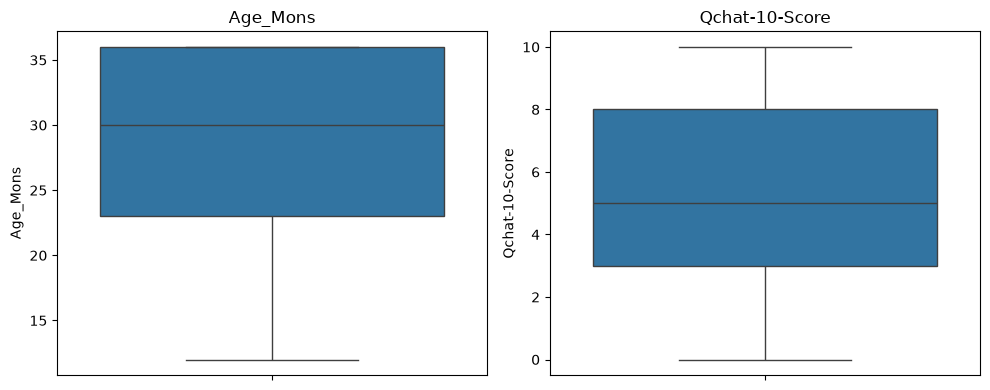

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, y="Age_Mons", ax=axes[0])
axes[0].set_title("Age_Mons")
sns.boxplot(data=df, y="Qchat-10-Score", ax=axes[1])
axes[1].set_title("Qchat-10-Score")
plt.tight_layout()
plt.show()

In [15]:
for col in ["Age_Mons", "Qchat-10-Score"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)]
    print(f"{col}: {len(outliers)} possíveis outliers")

Age_Mons: 0 possíveis outliers
Qchat-10-Score: 0 possíveis outliers


## Visualizações e relações entre variáveis

Gráficos de relação com `Class/ASD Traits`. O escore Q-CHAT separa melhor as classes do que a idade; Sex, Jaundice e Family_mem_with_ASD entram só como padrões descritivos; A1–A10 correlacionam com o escore total. Interpretação exclusivamente acadêmica.


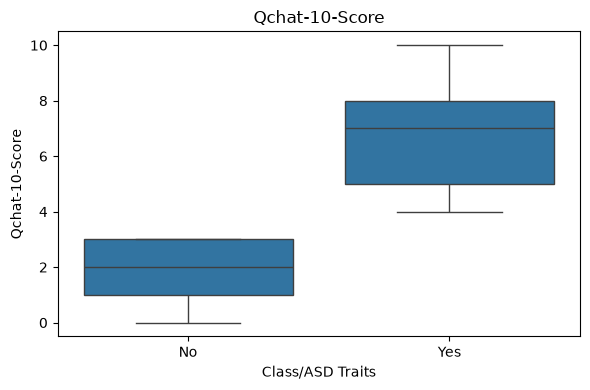

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Class/ASD Traits", y="Qchat-10-Score", ax=ax)
ax.set_title("Qchat-10-Score")
plt.tight_layout()
plt.show()


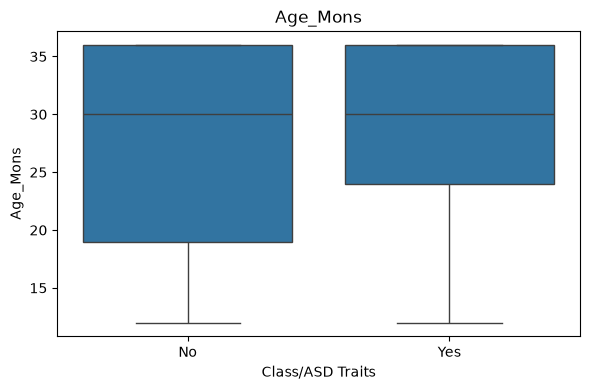

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="Class/ASD Traits", y="Age_Mons", ax=ax)
ax.set_title("Age_Mons")
plt.tight_layout()
plt.show()


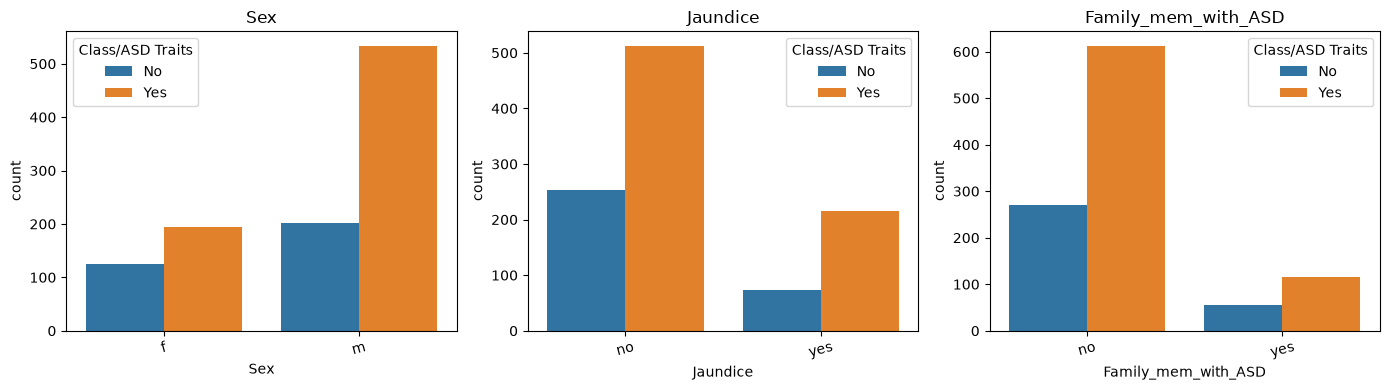


Proporção de Class/ASD Traits por Sex:
Class/ASD Traits     No    Yes
Sex                           
f                 0.392  0.608
m                 0.273  0.727

Proporção de Class/ASD Traits por Jaundice:
Class/ASD Traits     No    Yes
Jaundice                      
no                0.330  0.670
yes               0.253  0.747

Proporção de Class/ASD Traits por Family_mem_with_ASD:
Class/ASD Traits        No    Yes
Family_mem_with_ASD              
no                   0.307  0.693
yes                  0.324  0.676


In [18]:
cat_vs_class = ["Sex", "Jaundice", "Family_mem_with_ASD"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_vs_class):
    sns.countplot(data=df, x=col, hue="Class/ASD Traits", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

for col in cat_vs_class:
    print(f"\nProporção de Class/ASD Traits por {col}:")
    print(pd.crosstab(df[col], df["Class/ASD Traits"], normalize="index").round(3))


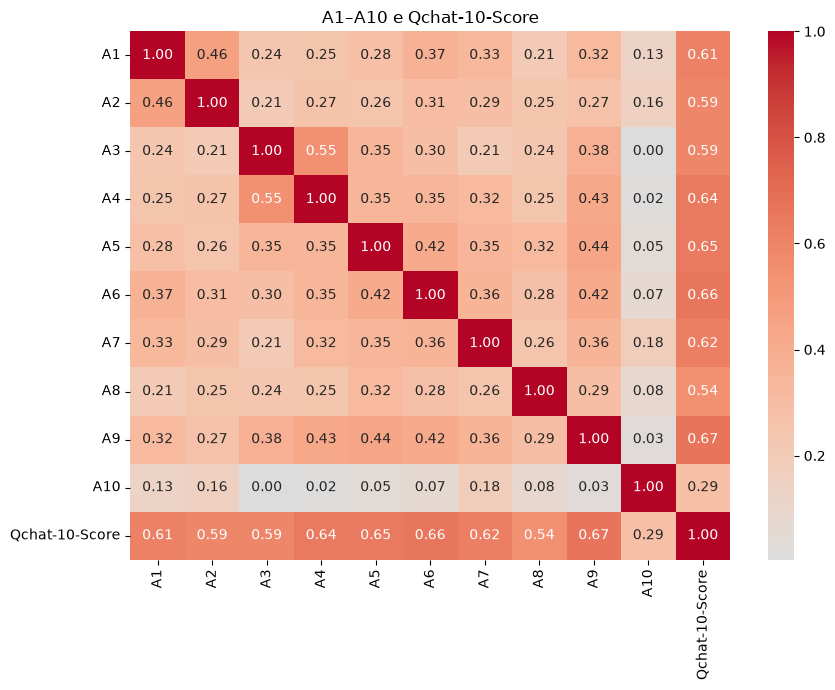

In [19]:
a_cols = [f"A{i}" for i in range(1, 11)]
corr_cols = a_cols + ["Qchat-10-Score"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("A1–A10 e Qchat-10-Score")
plt.tight_layout()
plt.show()


## Preparação dos dados para Machine Learning

Codificação das categóricas com `get_dummies`, definição de X/y e separação estratificada treino/teste (80/20). Nenhum modelo é treinado nesta etapa; os arquivos ficam em `data/processed/`.


In [20]:
feature_cols = a_cols + [
    "Age_Mons",
    "Qchat-10-Score",
    "Sex",
    "Jaundice",
    "Family_mem_with_ASD",
    "Ethnicity",
]
categorical_features = ["Sex", "Jaundice", "Family_mem_with_ASD", "Ethnicity"]

X = pd.get_dummies(df[feature_cols], columns=categorical_features, drop_first=True)
y = df["Class/ASD Traits"].map({"No": 0, "Yes": 1}).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

ml_features = X.copy()
ml_features["target"] = y

train_df = X_train.copy()
train_df["target"] = y_train
test_df = X_test.copy()
test_df["target"] = y_test

processed_dir = project_dir / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

ml_features_path = processed_dir / "ml_features.csv"
ml_train_path = processed_dir / "ml_train.csv"
ml_test_path = processed_dir / "ml_test.csv"

ml_features.to_csv(ml_features_path, index=False)
train_df.to_csv(ml_train_path, index=False)
test_df.to_csv(ml_test_path, index=False)

print(f"X shape: {X.shape}")
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")
print("\nProporção das classes (treino):")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporção das classes (teste):")
print(y_test.value_counts(normalize=True).round(3))
print("\nColunas de X:")
print(list(X.columns))
print(f"\nArquivos salvos:\n- {ml_features_path}\n- {ml_train_path}\n- {ml_test_path}")


X shape: (1054, 25)
Treino: (843, 25), Teste: (211, 25)

Proporção das classes (treino):
Class/ASD Traits
1    0.69
0    0.31
Name: proportion, dtype: float64

Proporção das classes (teste):
Class/ASD Traits
1    0.692
0    0.308
Name: proportion, dtype: float64

Colunas de X:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Qchat-10-Score', 'Sex_m', 'Jaundice_yes', 'Family_mem_with_ASD_yes', 'Ethnicity_Black', 'Ethnicity_Hispanic', 'Ethnicity_Latino', 'Ethnicity_Middle Eastern', 'Ethnicity_Mixed', 'Ethnicity_Native Indian', 'Ethnicity_Others', 'Ethnicity_Pacifica', 'Ethnicity_South Asian', 'Ethnicity_White European']

Arquivos salvos:
- ..\data\processed\ml_features.csv
- ..\data\processed\ml_train.csv
- ..\data\processed\ml_test.csv
